<font size="5"> <a href="https://uspdigital.usp.br/jupiterweb/obterDisciplina?sgldis=MAC0209"> Exercício de MAC0209 - Modelagem e Simulação</a> </font>

Derek Ferreira Queiróz - 16862040 \
Ezequiel Gomes de Carvalho - 15510880\
Leonardo Fraga Odloak - 14588277\
Lucas Pires da Silva - 16885060\
Luis Felipe Quireza Menezes de Oliveira - 15472606\
Matheus de Oliveira Teodoro da Silva - 14598104\
Milena de Paula Silva - 16965010\
Sandro Kenvi Mayorga Cáceres - 11262880

***
<font size="5"> EP2 - Primeiros modelos determinísticos </font>
***

# Setup

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import math
import matplotlib.pyplot as pyplot
import pandas as pd
import numpy as np
import sys






Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Main

In [ ]:
 # x(t)
def x(t,a, v_0,x_0):
  ''' (float,float,float,float) -> (float)
      Calcula a posição de uma partícula, em movimento uniformemente variado, em certo instante
      dado uma certa aceleração e uma certa velocidade inicial.
  '''
  return 1/2*a*(t**2) + v_0 *t + x_0

# v(t)
def v(t,a,v_0):
  ''' (float,float,float) -> (float)
      Calcula a velocidade de uma partícula, em movimento uniformemente variado, em certo instante
      dado uma certa aceleração e uma certa velocidade inicial.
  '''

  return a*t + v_0

def calcula_pos(tempo,a,v_0,x_0):
  ''' (array,float,float,float) -> (list)
      Calcula as posições em cada instante, contido em um array, de uma particula
      e retorna essas posições em uma lista chamado array_x.
  '''

  array_x = []
  for i in range(len(tempo)):
    array_x.append(x(tempo[i], a, v_0, x_0))

  return array_x

def calcula_vel(tempo,a,v_0):
  ''' (array,float,float) -> (list)
      Calcula as velocidades em cada instante contido em um array de uma particula
      e retorna essas velocidades em uma lista chamado array_v.
  '''

  array_v = []
  for i in range(len(tempo)):
    array_v.append(v(tempo[i], a, v_0))

  return array_v

def criar_teste(a,v_0,x_0,tempo,cor):
  ''' (float,float,array,str) -> (dic)
      Cria um dicionário para armazenar uma série de informações sobre um
      experimento com relação a velocidade e posição de uma
      partícula realizados com determindas medidas.
  '''

  array_v = calcula_vel(tempo,a,v_0)
  array_x = calcula_pos(tempo,a,v_0,x_0)

  teste = {}

  teste["vel"] = array_v
  teste["pos"] = array_x
  teste["a"] = a
  teste["v"] = v_0
  teste["cor"] = cor

  return teste

def comparar_pos(TESTES,tempo):
  ''' (list,array) -> (None)
      Plota em um gráfico todas as curvas de variação do espaço para cada teste.
  '''

  fig, ax = pyplot.subplots(figsize=(13, 10), layout='constrained')
  for teste_atual in TESTES:
    ax.plot(tempo, teste_atual["pos"], label=f'{teste_atual["a"]:.1f} m/s² e {teste_atual["v"]:.1f} m/s',color= teste_atual["cor"])

  ax.set_xlabel('Tempo (s)')
  ax.set_ylabel('Espaço (m)')
  ax.set_title("Espaço X Tempo para cada aceleração e velocidade inicial",color="black",fontweight="bold")
  ax.legend()

def comparar_vel(TESTES,tempo):
  ''' (list,array) -> (None)
      Plota em um gráfico todas as curvas de variação da velocidade para cada teste.
  '''
  fig, ax = pyplot.subplots(figsize=(13,10), layout='constrained')
  for teste_atual in TESTES:
    ax.plot(tempo, teste_atual["vel"], label=f'{teste_atual["a"]:.1f} m/s² e {teste_atual["v"]:.1f} m/s',color= teste_atual["cor"])

  ax.set_xlabel('Tempo (s)')
  ax.set_ylabel('Velocidade (m/s)')
  ax.set_title("Velocidade X Tempo para cada aceleração e velocidade inicial",color="black",fontweight="bold")
  ax.legend()

def apresentar_pos(TESTES,tempo):
  ''' (list,array) -> (None)
      Plota em um gráfico as curvas de variação da posição
      e velocidade inicial.
  '''
  n = len(TESTES)

  nlins = 2 # define o número de linhas da representação dos gráficos
  ncols = n//2

  fig, axs = pyplot.subplots(nlins,ncols, figsize=(27, 8)) # cria um array de 2 linhas e 5 colunas

  for i, ax in enumerate(axs.flatten()): # converte em um array unidimensional de 10 elementos
      teste_atual = TESTES[i]
      a_atual = teste_atual["a"]
      v_atual = teste_atual["v"]

      y = teste_atual["pos"]
      x = tempo

      cor = teste_atual["cor"]

      ax.plot(x,y,color=cor) # para cada coluna plotamos no gr
      ax.set_title(f"a = {a_atual:.2f} m/s^2 ; v = {v_atual:.2f} m/s")
      ax.set_xlabel("Tempo (s)")
      ax.set_ylabel("Espaço (m)")

  pyplot.subplots_adjust(wspace=0.5, hspace=0.5)
  pyplot.show()

def apresentar_vel(TESTES,tempo):
  ''' (list,array) -> (None)
      Plota em um gráfico as curvas de variação da velocidade para uma
      dada aceleração e velocidade inicial.
  '''
  n = len(TESTES)

  nlins = 2
  ncols = n//2

  fig, axs = pyplot.subplots(nlins,ncols, figsize=(27, 8)) # cria um array de 2 linhas e 5 colunas
  cores = ["purple","green","blue","red","orange","magenta","cyan","red","yellow","black"]

  for i, ax in enumerate(axs.flatten()): # converte em um array unidimensional de 10 elementos
      teste_atual = TESTES[i]
      a_atual = teste_atual["a"]
      v_atual = teste_atual["v"]

      y = teste_atual["vel"]
      x = tempo

      cor = teste_atual["cor"]

      ax.plot(x,y,color=cor) # para cada coluna plotamos no gr
      ax.set_title(f"a = {a_atual:.2f} m/s^2 ; v = {v_atual:.2f} m/s")
      ax.set_xlabel("Tempo (s)")
      ax.set_ylabel("Velocidade (m/s)")

  pyplot.subplots_adjust(wspace=0.5, hspace=0.5)
  pyplot.show()

In [ ]:
# Criar os testes com os parametros variando da seguinte forma:
tempo = np.linspace(0,10,100)
a_samples = np.linspace(-20,20,10) # Selecionando 10 acelerações do intervalo de -20 m/s até 20 m/s de maneira uniforme
v_samples = np.linspace(-30,30,10) # Selecionando 10 velocidades do intervalo de -30 m/s até 30 m/s de maneira uniforme

# Escolhendo as cores de gráfico de cada teste
cores = ["purple","green","blue","red","orange","magenta","cyan","red","yellow","black"]

# Gerando os testes e salvando em uma lista
TESTES = []
for i in range(len(a_samples)):
  vel_atual = v_samples[i]
  a_atual = a_samples[i]

  teste_atual = criar_teste(a_atual,vel_atual, 0,tempo,cores[i])
  TESTES.append(teste_atual)

**Variação da Posição**

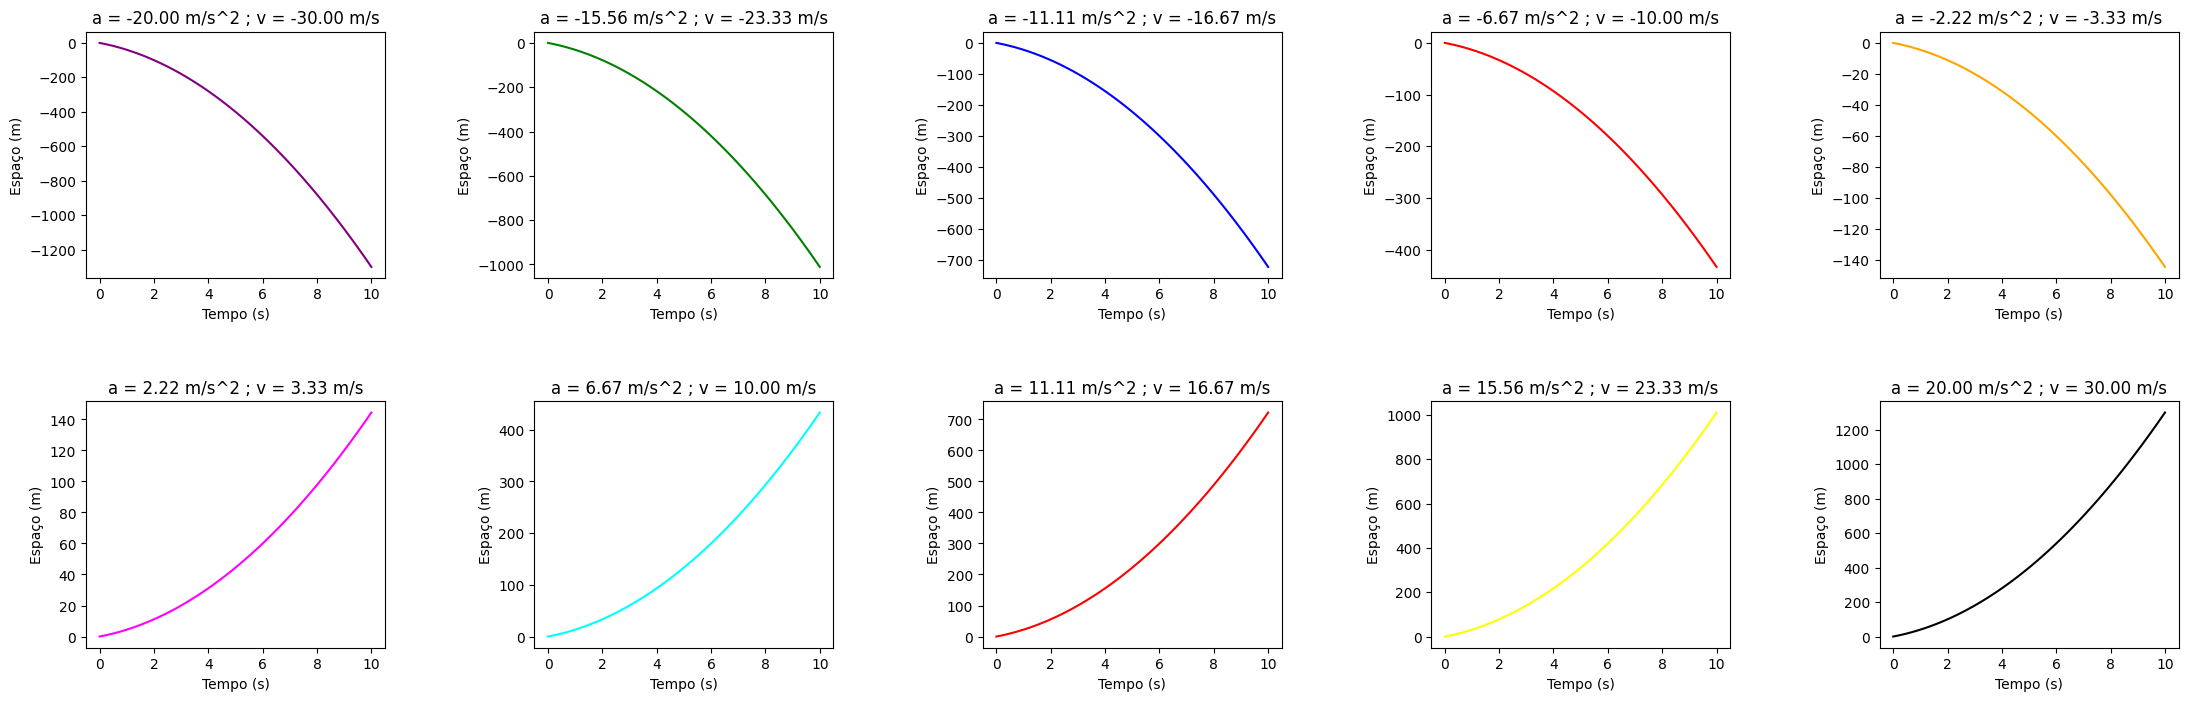

In [ ]:
apresentar_pos(TESTES,tempo)

**Variação da Velocidade**

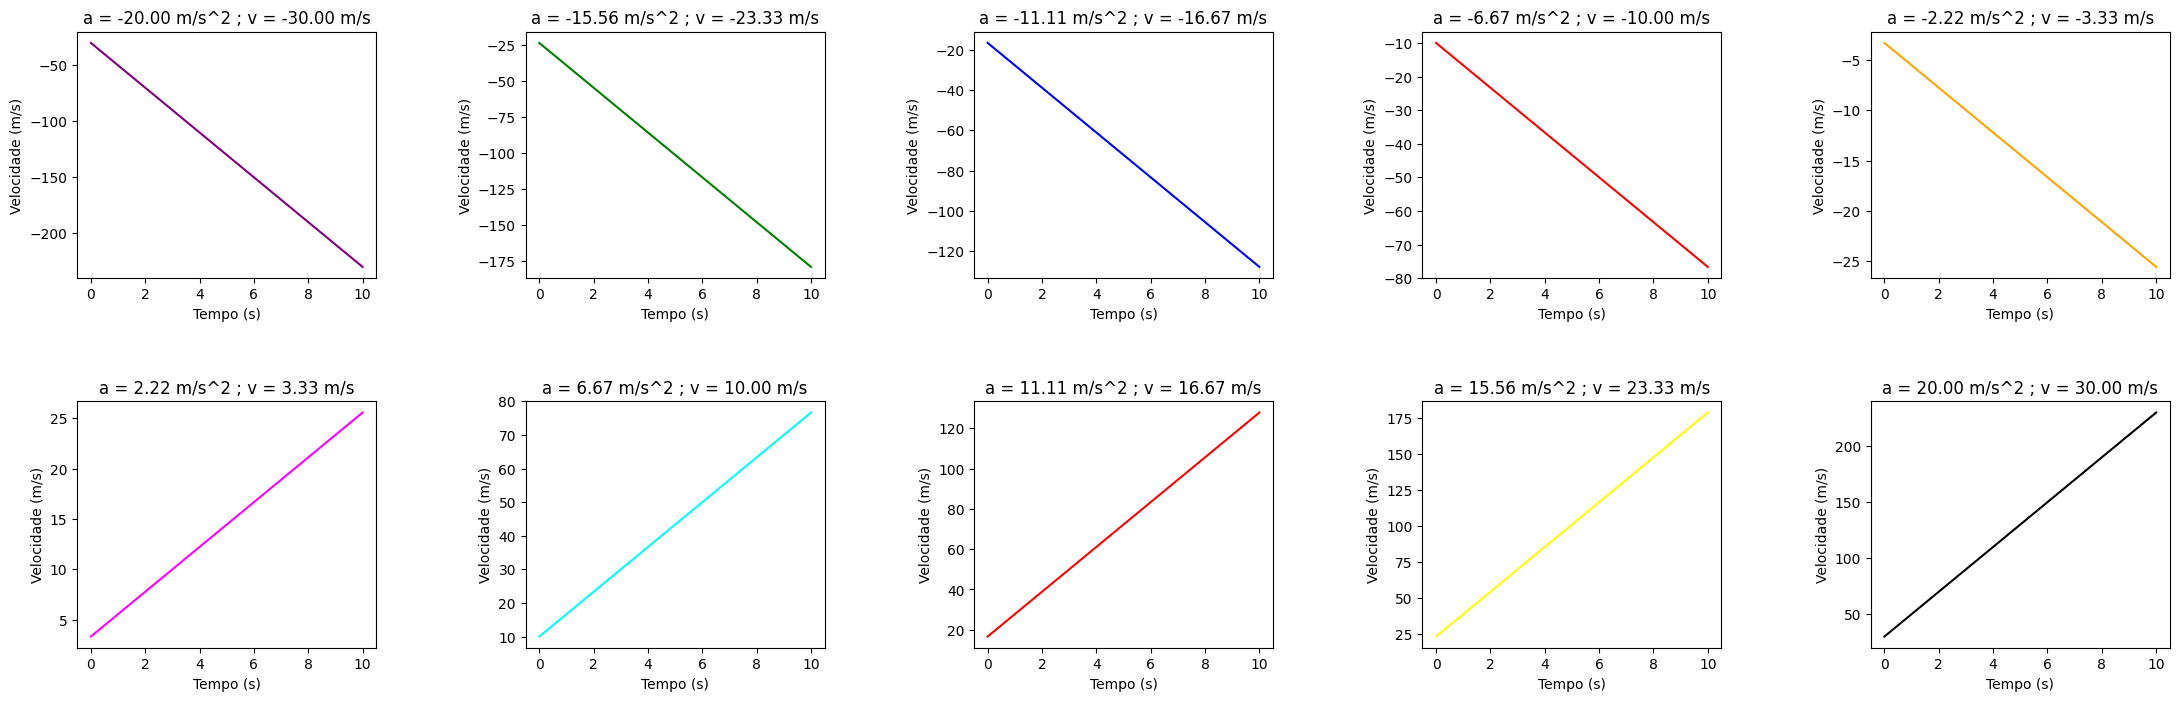

In [ ]:
apresentar_vel(TESTES,tempo)

**Variações da Posição no mesmo gráfico**

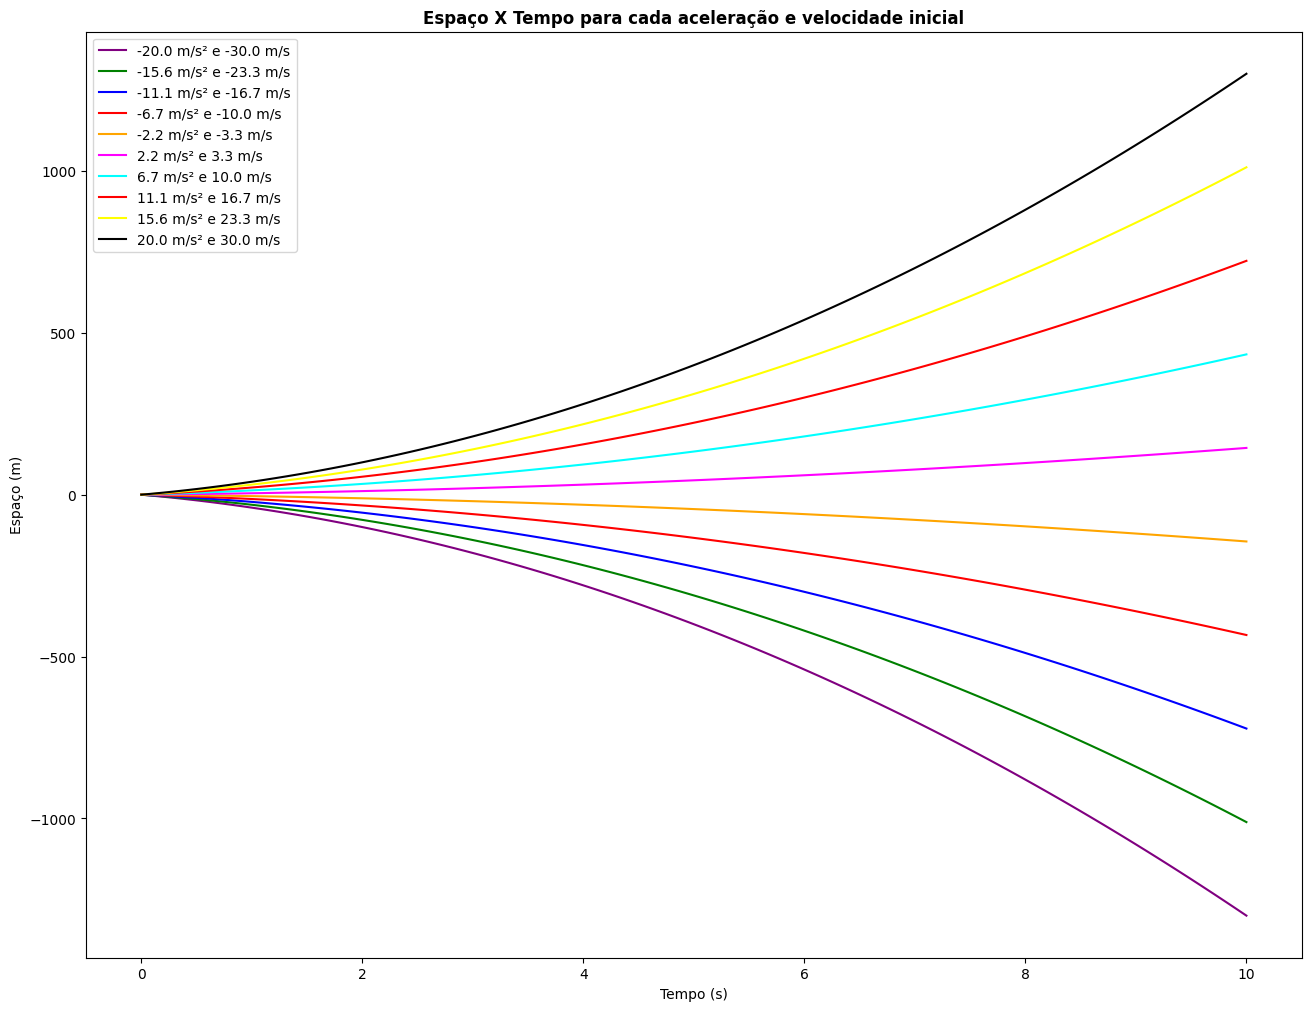

In [ ]:
comparar_pos(TESTES,tempo)

**Variações da Velocidade no mesmo gráfico**

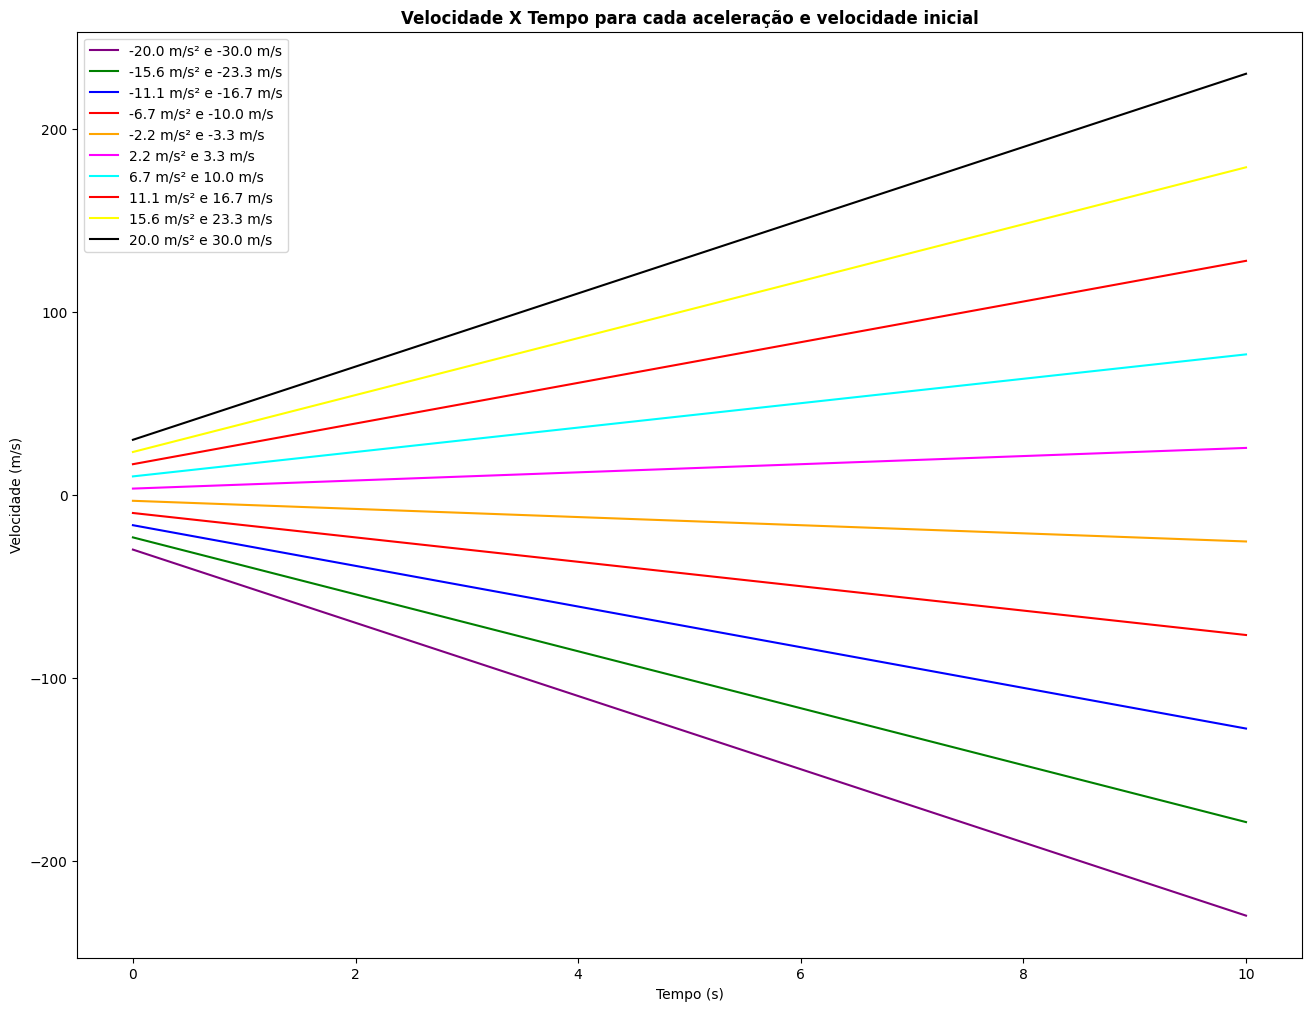

In [ ]:
comparar_vel(TESTES,tempo)